In [33]:
import os
import sys
import spacy
import importlib
import config
importlib.reload(config)

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

data_path_kafka = os.path.join(module_path, r"data\kafka_korpus")
data_path_vergleichskorpus = os.path.join(module_path, r"data\Vergleichskorpus\corpus")


def read_txt_file(file_path):
    """
    Read a single txt file and return its content as a string.

    """
    with open(file_path, 'r', encoding='utf-8') as f:
        text = f.read()
    return text

def read_files_from_folders(folders: list[str]) -> list[dict]:
    from os import listdir
    from os.path import isfile, join

    files = {}
    for folder in folders:

        for f in listdir(folder):
            if isfile(join(folder, f)):
                name = os.path.splitext(f)[0]
                files[name] = os.path.join(folder, f)
        
    return files


# Syntaktische Analyse

Ziel ist es doppelte negationen herauszufinden, meist durch "nicht" gekennzeichnet, z.B. "nicht unsicher"

### Unterscheidung Doppelnegationen:
- Syntaktische Doppelnegation: Zwei separate Negationswörter beziehen sich auf dasselbe Prädikat (z. B. "Ich habe nicht nichts getan").
- Morpho-Syntaktische Doppelnegation: Ein Negationspartikel trifft auf ein Wort mit negierendem Präfix (z. B. "Das ist nicht unüblich")

### Operationalisierung
Eine Doppelnegation liegt vor, wenn **innerhalb desselben Teilsatzes** (d. h. ohne Nebensatzgrenze zu überschreiten) zwei negierende Elemente in einer syntaktischen Abhängigkeitsbeziehung stehen.

**Logik in spaCy:**

1. Iteriere über alle Tokens im Satz.
2. Identifiziere Negationspartikeln (`nicht`, `nie`, …) anhand von POS-Tag (`PART`, `ADV`) und Lemma.
3. Bestimme den **Kopf (head)** der Negation im Dependenzbaum.
4. Durchsuche den **Subtree** dieses Kopfes (nicht nur direkte Kinder), aber **exkludiere untergeordnete Nebensätze** (erkennbar an `dep ∈ {rc, cp, …}` oder subordinierenden Konjunktionen).
5. Prüfe auf **syntaktische Doppelnegation**: Gibt es im selben Subtree ein zweites negierendes Element (z. B. `nichts`, `niemand`, `kein`, weiteres `nicht`)?
6. Prüfe auf **morpho-syntaktische Doppelnegation**: Hat der Kopf der Negation (oder dessen prädikatives Adjektiv/Partizip im Subtree) ein negierendes Präfix (`un-`, `miss-`, …), das nicht in der Ausschlussliste steht?


In [19]:
nlp = spacy.load(config.SPACY_MODEL_DE)

In [24]:
'''
Schritt 2
'''
NEGATION_TOKENS = {
    # (lemma, pos): typ
    ("nicht", "PART"): "partikel",
    ("nie", "ADV"): "adverb",
    ("niemals", "ADV"): "adverb",
    ("nirgends", "ADV"): "adverb",
    ("nirgendwo", "ADV"): "adverb",
    ("nichts", "PRON"): "pronomen",
    ("niemand", "PRON"): "pronomen",
    ("kein", "DET"): "determiner",
    ("weder", "CCONJ"): "konjunktion",
}

def is_negation(token) -> bool:
    """Prüft ob ein Token ein negierendes Element ist."""
    return (token.lemma_.lower(), token.pos_) in NEGATION_TOKENS

# Zusätzlich: dep-Label 'ng' ist der direkteste Weg für 'nicht'
def is_negation_particle(token) -> bool:
    """Prüft spezifisch auf Negationspartikel via Dependency-Label."""
    return token.dep_ == "ng"

NEGATIVE_PREFIXES = ["un", "miss"]
LEXICALIZED_EXCEPTIONS = {"ungeheuer", "unfug", "unkosten", "ungeziefer", "umstand", "umstände"}

CLAUSE_BOUNDARY_DEPS = {"rc", "cp", "cj", "oc", "re"}

def get_clause_head(token):
    """
    Wandert im Dependenzbaum nach oben und gibt den nächsten
    Clause-Kopf (Verb/Aux mit clause-boundary dep oder ROOT) zurück.
    So wird bestimmt, zu welchem Teilsatz ein Token gehört.
    """
    current = token
    while current.head != current:  # solange nicht ROOT
        if current.dep_ in CLAUSE_BOUNDARY_DEPS and current.pos_ in {"VERB", "AUX"}:
            return current
        if current.dep_ == "ROOT":
            return current
        current = current.head
    return current  # ROOT

def same_clause(token_a, token_b) -> bool:
    """Prüft ob zwei Tokens im selben Teilsatz liegen."""
    return get_clause_head(token_a) == get_clause_head(token_b)

def get_clause_subtree(head_token):
    """Subtree des Kopfes, nur Tokens aus demselben Teilsatz."""
    clause_head = get_clause_head(head_token)
    result = []
    for token in head_token.subtree:
        if get_clause_head(token) == clause_head:
            result.append(token)
    return result

def has_negative_prefix(token) -> bool:
    """Schritt 6 (morpho-syntaktisch): Prüft auf negierendes Präfix."""
    word = token.text.lower()
    if word in LEXICALIZED_EXCEPTIONS:
        return False
    return any(word.startswith(prefix) for prefix in NEGATIVE_PREFIXES)

def find_double_negations(doc) -> list[dict]:
    results = []
    
    for sent in doc.sents:
        negations = [t for t in sent if is_negation(t) or is_negation_particle(t)]
        
        already_paired = set()
        
        for neg_token in negations:
            if neg_token.i in already_paired:
                continue
                
            head = neg_token.head
            subtree = get_clause_subtree(head)
            
            # --- Syntaktische Doppelnegation ---
            for other in subtree:
                if (other.i != neg_token.i 
                    and other.i not in already_paired
                    and (is_negation(other) or is_negation_particle(other))
                    and same_clause(neg_token, other)):  # ← NEU
                    results.append({
                        "typ": "syntaktisch",
                        "negation_1": neg_token.text,
                        "negation_2": other.text,
                        "head": head.text,
                        "clause_head": get_clause_head(neg_token).text,
                        "satz": sent.text,
                    })
                    already_paired.add(other.i)
            
            # --- Morpho-syntaktische Doppelnegation ---
            for other in subtree:
                if (other.i != neg_token.i 
                    and has_negative_prefix(other)
                    and same_clause(neg_token, other)):  # ← NEU
                    results.append({
                        "typ": "morpho-syntaktisch",
                        "negation_1": neg_token.text,
                        "prefixed_word": other.text,
                        "head": head.text,
                        "clause_head": get_clause_head(neg_token).text,
                        "satz": sent.text,
                    })
    
    return results

In [28]:
# Testsätze um die Tags zu inspizieren
test_sentences = [
    "Ich habe nicht nichts getan und das ist nicht ungewöhnlich.",
    "Das ist nicht unüblich.",
    "Niemand hat ihn nie gesehen.",
    "Er hat keine Angst.",
    "Sie aber haben eine solche Erlaubnis nicht oder haben sie wenigstens nicht vorgezeigt.",
    "Seine Vorstellung war nicht mehr vollständig unabhängig vom Ausgang des Prozesses"
]

for sent in test_sentences:
    doc = nlp(sent)
    print(f"\n--- {sent} ---")
    results = find_double_negations(doc)
    for r in results:
        print(r["typ"], r)



--- Ich habe nicht nichts getan und das ist nicht ungewöhnlich. ---
syntaktisch {'typ': 'syntaktisch', 'negation_1': 'nicht', 'negation_2': 'nichts', 'head': 'nichts', 'clause_head': 'getan', 'satz': 'Ich habe nicht nichts getan und das ist nicht ungewöhnlich.'}
morpho-syntaktisch {'typ': 'morpho-syntaktisch', 'negation_1': 'nicht', 'prefixed_word': 'ungewöhnlich', 'head': 'ist', 'clause_head': 'ist', 'satz': 'Ich habe nicht nichts getan und das ist nicht ungewöhnlich.'}

--- Das ist nicht unüblich. ---
morpho-syntaktisch {'typ': 'morpho-syntaktisch', 'negation_1': 'nicht', 'prefixed_word': 'unüblich', 'head': 'ist', 'clause_head': 'ist', 'satz': 'Das ist nicht unüblich.'}

--- Niemand hat ihn nie gesehen. ---

--- Er hat keine Angst. ---

--- Sie aber haben eine solche Erlaubnis nicht oder haben sie wenigstens nicht vorgezeigt. ---

--- Seine Vorstellung war nicht mehr vollständig unabhängig vom Ausgang des Prozesses ---
morpho-syntaktisch {'typ': 'morpho-syntaktisch', 'negation_1': 

In [30]:
das_schloss = read_txt_file(os.path.join(module_path, r"roman_fragmente\das_schloss.txt"))
sents = [sent.text for sent in nlp(das_schloss).sents]
print(len(sents))

3782


In [34]:
das_schloss = read_txt_file(os.path.join(data_path_vergleichskorpus, r"ThMann_Zauberberg1.txt"))
sents = [sent.text for sent in nlp(das_schloss).sents]
print(len(sents))

7552


In [35]:
all_results = []
for sent in sents:
    doc = nlp(sent)
    results = find_double_negations(doc)
    for r in results:
        all_results.append(r)

for r in all_results:
    print(f"[{r['typ']}] {r['satz']}")
    if r['typ'] == 'syntaktisch':
        print(f"  → {r['negation_1']} ... {r['negation_2']} (head: {r['head']})")
    else:
        print(f"  → {r['negation_1']} + {r['prefixed_word']} (head: {r['head']})")
    print()

print(f"Gesamt: {len(all_results)} Doppelnegationen gefunden.")

[morpho-syntaktisch] Es steht jedoch
so mit ihr, wie es heute auch mit den Menschen und unter diesen nicht
zum wenigsten mit den Geschichtenerzählern steht: sie ist viel älter als
ihre Jahre, ihre Betagtheit ist nicht nach Tagen, das Alter, das auf ihr
liegt, nicht nach Sonnenumläufen zu berechnen;
  → nicht + und (head: steht)

[morpho-syntaktisch] Es steht jedoch
so mit ihr, wie es heute auch mit den Menschen und unter diesen nicht
zum wenigsten mit den Geschichtenerzählern steht: sie ist viel älter als
ihre Jahre, ihre Betagtheit ist nicht nach Tagen, das Alter, das auf ihr
liegt, nicht nach Sonnenumläufen zu berechnen;
  → nicht + unter (head: steht)

[morpho-syntaktisch] Aber ist der
Vergangenheitscharakter einer Geschichte nicht desto tiefer,
vollkommener und märchenhafter, je dichter „vorher“ sie spielt?
  → nicht + und (head: tiefer)

[morpho-syntaktisch] Die sieben Tage einer Woche werden dazu nicht reichen und
auch sieben Monate nicht.
  → nicht + und (head: reichen)

[morpho

# Daten-Pipeline

Die gesamte Datenproduktion ist in `pipeline.py` ausgelagert. Konfiguration (Werkauswahl, Ausschlüsse) erfolgt über `config.py`.

### Drei DataFrames

**`df_saetze`** — eine Zeile pro Satz (Kern-Tabelle)
| Spalte | Beschreibung |
|---|---|
| `werk_id` | Dateiname ohne .txt |
| `autor` | "Kafka" bzw. aus Dateiname geparst |
| `korpus` | "kafka" / "vergleich" |
| `satz_id` | Laufende Nummer im Werk (0-basiert) |
| `satz` | Satztext |
| `n_tokens` | Anzahl alphabetischer Tokens |
| `n_chars` | Zeichenlänge |
| `satz_position` | Relative Position im Werk (0.0–1.0) |

**`df_morpho`** — eine Zeile pro un-Wort-Vorkommen (Token-Ebene)
| Spalte | Beschreibung |
|---|---|
| `werk_id` | FK → df_saetze |
| `satz_id` | FK → df_saetze |
| `token_text` | Originalform ("unruhig") |
| `lemma` | Lemma ("unruhig") |
| `rest` | Stamm ohne Präfix ("ruhig") |
| `pos_tag` | ADJ / NOUN / ADV / VERB |
| `validierung` | "wordfreq" / "suffix_heuristik" |

**`df_syntax`** — eine Zeile pro Doppelnegation
| Spalte | Beschreibung |
|---|---|
| `werk_id` | FK → df_saetze |
| `satz_id` | FK → df_saetze |
| `typ` | "syntaktisch" / "morpho-syntaktisch" |
| `negation_1` | Erstes Negationselement |
| `negation_2` | Zweites Element (syntaktisch) oder NaN |
| `prefixed_word` | Präfigiertes Wort (morpho-synt.) oder NaN |
| `clause_head` | Kopf des Teilsatzes |
| `dep_relation` | Dep-Label der Negation |

### Metriken (ableitbar aus den DataFrames)
- Doppelnegationen / Gesamtsätze (pro Werk)
- Doppelnegation nach Typ (syntaktisch vs. morpho-syntaktisch)
- un-Wörter / 1000 Tokens
- un-Wörter / Satz
- Negationsdichte (alle Negationswörter / 1000 Tokens)
- Häufigste Negationsformen
- Verteilung über das Werk (via satz_position)

In [46]:
import importlib
import pipeline
importlib.reload(config)
importlib.reload(pipeline)

# Pipeline ausführen — beide Korpora
df_saetze, df_morpho, df_syntax = pipeline.run_pipeline(nlp, base_path=module_path, korpus= "beide")

# CSV-Export
output_path = os.path.join(module_path, "output")
os.makedirs(output_path, exist_ok=True)

df_saetze.to_csv(os.path.join(output_path, "df_saetze.csv"), index=False, encoding="utf-8")

df_morpho.to_csv(os.path.join(output_path, "df_morpho.csv"), index=False, encoding="utf-8")
df_syntax.to_csv(os.path.join(output_path, "df_syntax.csv"), index=False, encoding="utf-8")

print(f"\nCSV-Dateien gespeichert in: {output_path}")
print(df_syntax.head(10))

  ⏭ auf_der_galerie übersprungen (~2 Sätze < 100)
  ⏭ blumfeld_ein_älterer_junggeselle übersprungen (~90 Sätze < 100)
  ⏭ das_ehepaar übersprungen (~68 Sätze < 100)
  ⏭ das_naechste_dorf übersprungen (~1 Sätze < 100)
  ⏭ das_schweigen_der_sirenen übersprungen (~18 Sätze < 100)
  ⏭ das_stadtwappen übersprungen (~17 Sätze < 100)
  ⏭ der_aufbruch übersprungen (~10 Sätze < 100)
  ⏭ der_geier übersprungen (~8 Sätze < 100)
  ⏭ der_jaeger_gracchus übersprungen (~81 Sätze < 100)
  ⏭ der_kreisel übersprungen (~7 Sätze < 100)
  ⏭ der_kuebelreiter übersprungen (~30 Sätze < 100)
  ⏭ der_nachbar übersprungen (~30 Sätze < 100)
  ⏭ der_schlag_ans_hoftor übersprungen (~31 Sätze < 100)
  ⏭ die_bruecke übersprungen (~25 Sätze < 100)
  ⏭ die_pruefung übersprungen (~19 Sätze < 100)
  ⏭ die_sorge_des_hausvaters übersprungen (~24 Sätze < 100)
  ⏭ die_truppenaushebung übersprungen (~27 Sätze < 100)
  ⏭ die_wahrheit_über_sancho_pansa übersprungen (~1 Sätze < 100)
  ⏭ ein_altes_blatt übersprungen (~39 Sätze < 

In [47]:
# Schnellübersicht
print(f"=== df_saetze: {len(df_saetze)} Zeilen ===")
print(df_saetze.groupby("korpus")[["n_tokens"]].agg(["count", "sum"]))

print(f"\n=== df_morpho: {len(df_morpho)} negierte Affixe ===")
if "affix" in df_morpho.columns:
    print(df_morpho.groupby(["affix_typ", "affix"]).size().reset_index(name="count").sort_values("count", ascending=False))
print()
print(df_morpho.head(10))

print(f"\n=== df_syntax: {len(df_syntax)} Doppelnegationen ===")
print(df_syntax.head(10))

=== df_saetze: 136594 Zeilen ===
          n_tokens         
             count      sum
korpus                     
kafka        18056   355820
vergleich   118538  1585900

=== df_morpho: 11257 negierte Affixe ===
  affix_typ  affix  count
4    präfix     un   8816
6    suffix    los   2272
3    präfix  nicht    103
5    suffix   frei     35
1    präfix     ir     18
2    präfix   miss      9
0    präfix     il      4

   werk_id  satz_id          token_text               lemma affix_typ  affix  \
0  amerika       20         unversehens         unversehens    präfix     un   
1  amerika       22         unbehaglich         unbehaglich    präfix     un   
2  amerika       59  Nichteingestandene  nichteingestandene    präfix  nicht   
3  amerika       73      unvergleichbar      unvergleichbar    präfix     un   
4  amerika       97          unsicheren            unsicher    präfix     un   
5  amerika       97         unbekannten           unbekannt    präfix     un   
6  amerika      

In [49]:
# Inspektion: Neue Affixe auf False Positives prüfen
# Lateinische Präfixe + Suffixe separat anzeigen

neue_affixe = df_morpho[df_morpho["affix"].isin(["in", "il", "ir", "a", "an", "non", "des", "dis", "los", "frei"])]
print(f"Funde mit neuen Affixen: {len(neue_affixe)}")
print()

for affix, group in neue_affixe.groupby("affix"):
    unique = group[["lemma", "rest", "affix_typ"]].drop_duplicates().sort_values("lemma")
    print(f"── {affix} ({len(group)} Vorkommen, {len(unique)} Types) ──")
    for _, row in unique.iterrows():
        print(f"  {row['lemma']:25s} → {row['rest']:20s} ({row['affix_typ']})")
    print()

Funde mit neuen Affixen: 2329

── frei (35 Vorkommen, 16 Types) ──
  alkoholfrei               → alkohol              (suffix)
  altfrei                   → alt                  (suffix)
  baumfrei                  → baum                 (suffix)
  dienstfrei                → dienst               (suffix)
  einwandfrei               → einwand              (suffix)
  fieberfrei                → fieber               (suffix)
  fußfrei                   → fuß                  (suffix)
  honorarfrei               → honorar              (suffix)
  kostenfrei                → koste                (suffix)
  schneefrei                → schnee               (suffix)
  schuldenfrei              → schulde              (suffix)
  schulfrei                 → schul                (suffix)
  sorgenfrei                → sorge                (suffix)
  staubfrei                 → staub                (suffix)
  vorwurfsfrei              → vorwurf              (suffix)
  zweifelsfrei              → zwe

# Statistische Analyse — Mann-Whitney-U-Test

**H₀**: Kafka benutzt nicht signifikant mehr Negierungen als die anderen Autoren im Datensatz.  
**H₁**: Kafka benutzt signifikant mehr Negierungen (einseitig).

Beobachtungseinheit = **Werk**. Pro Werk wird eine Rate berechnet, dann Gruppe Kafka vs. Vergleich verglichen.

Getestet werden drei Metriken:
1. **Morphologische Negationen / 1000 Tokens** (un-, miss-, -los, -frei, ...)
2. **Doppelnegationen / 100 Sätze**
3. **Anteil Sätze mit mindestens einer morphologischen Negation (%)**

In [50]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# ── 1. Daten aus Output laden ──────────────────────────────────
df_saetze = pd.read_csv(os.path.join(module_path, "output", "df_saetze.csv"))
df_morpho = pd.read_csv(os.path.join(module_path, "output", "df_morpho.csv"))
df_syntax = pd.read_csv(os.path.join(module_path, "output", "df_syntax.csv"))

# ── 2. Werk-Level Statistiken berechnen ────────────────────────
werk_stats = df_saetze.groupby(["werk_id", "korpus", "autor"]).agg(
    n_saetze=("satz_id", "count"),
    n_tokens=("n_tokens", "sum"),
).reset_index()

# Morphologische Negationen pro Werk
morpho_counts = df_morpho.groupby("werk_id").size().rename("n_morpho_neg")
werk_stats = werk_stats.merge(morpho_counts, on="werk_id", how="left")
werk_stats["n_morpho_neg"] = werk_stats["n_morpho_neg"].fillna(0).astype(int)

# Sätze mit mind. einer morphologischen Negation
saetze_mit_neg = df_morpho.groupby("werk_id")["satz_id"].nunique().rename("n_saetze_mit_neg")
werk_stats = werk_stats.merge(saetze_mit_neg, on="werk_id", how="left")
werk_stats["n_saetze_mit_neg"] = werk_stats["n_saetze_mit_neg"].fillna(0).astype(int)

# Doppelnegationen pro Werk
dn_counts = df_syntax.groupby("werk_id").size().rename("n_doppelneg")
werk_stats = werk_stats.merge(dn_counts, on="werk_id", how="left")
werk_stats["n_doppelneg"] = werk_stats["n_doppelneg"].fillna(0).astype(int)

# ── 3. Raten berechnen ─────────────────────────────────────────
werk_stats["morpho_per_1000"] = werk_stats["n_morpho_neg"] / werk_stats["n_tokens"] * 1000
werk_stats["dn_per_100_saetze"] = werk_stats["n_doppelneg"] / werk_stats["n_saetze"] * 100
werk_stats["pct_saetze_mit_neg"] = werk_stats["n_saetze_mit_neg"] / werk_stats["n_saetze"] * 100

print(f"Werke gesamt: {len(werk_stats)}")
print(f"  Kafka:     {len(werk_stats[werk_stats['korpus'] == 'kafka'])}")
print(f"  Vergleich: {len(werk_stats[werk_stats['korpus'] == 'vergleich'])}")
print()
print(werk_stats[["werk_id", "korpus", "n_saetze", "n_tokens", "morpho_per_1000", "dn_per_100_saetze", "pct_saetze_mit_neg"]].to_string(index=False))

Werke gesamt: 62
  Kafka:     18
  Vergleich: 44

                                   werk_id    korpus  n_saetze  n_tokens  morpho_per_1000  dn_per_100_saetze  pct_saetze_mit_neg
                 Beer-Hofmann_DerTodGeorgs vergleich      2176     36798        10.652753           0.965074           15.808824
                              Benn_Gehirne vergleich       943     12444         5.464481           0.848356            6.362672
        Brod_ArnoldBeerSchicksalEinesJuden vergleich      2243     44309         7.718522           2.407490           12.572448
                       Ehrenstein_Tubutsch vergleich       616      8874         7.888213           1.948052            9.902597
                Ehrenstein_Zauberma╠êrchen vergleich       585     10949         7.215271           1.880342           11.452991
                    George_DerSiebenteRing vergleich      1728     17186         4.189457           0.810185            3.993056
                  George_DerSternDesBundes verg

In [51]:
# ── 4. Mann-Whitney-U-Test ──────────────────────────────────────
# H₀: Kafka benutzt nicht signifikant mehr Negierungen
# H₁: Kafka benutzt mehr (einseitig → alternative="greater")

kafka = werk_stats[werk_stats["korpus"] == "kafka"]
vergleich = werk_stats[werk_stats["korpus"] == "vergleich"]

metriken = {
    "Morpho. Negationen / 1000 Tokens": "morpho_per_1000",
    "Doppelnegationen / 100 Sätze":     "dn_per_100_saetze",
    "% Sätze mit Negation":             "pct_saetze_mit_neg",
}

results = []

for label, col in metriken.items():
    kafka_vals = kafka[col].values
    vergl_vals = vergleich[col].values
    
    # Mann-Whitney U (einseitig: Kafka > Vergleich)
    U, p = mannwhitneyu(kafka_vals, vergl_vals, alternative="greater")
    
    # Effektstärke: rank-biserial correlation
    n1, n2 = len(kafka_vals), len(vergl_vals)
    r_rb = 1 - (2 * U) / (n1 * n2)
    
    results.append({
        "Metrik": label,
        "Kafka Median": f"{np.median(kafka_vals):.2f}",
        "Kafka Mean":   f"{np.mean(kafka_vals):.2f}",
        "Vergl. Median": f"{np.median(vergl_vals):.2f}",
        "Vergl. Mean":   f"{np.mean(vergl_vals):.2f}",
        "U-Statistik": f"{U:.0f}",
        "p-Wert":      f"{p:.4f}",
        "Effektstärke r": f"{r_rb:.3f}",
        "Signifikant (α=0.05)": "✅ Ja" if p < 0.05 else "❌ Nein",
    })

df_results = pd.DataFrame(results)
print("=" * 80)
print("Mann-Whitney-U-Test: Kafka vs. Vergleichskorpus (einseitig, H₁: Kafka > Vergl.)")
print("=" * 80)
print()
print(df_results.to_string(index=False))
print()
print("Interpretation Effektstärke r (rank-biserial):")
print("  |r| < 0.1: vernachlässigbar")
print("  |r| 0.1–0.3: klein")
print("  |r| 0.3–0.5: mittel")
print("  |r| > 0.5: groß")

Mann-Whitney-U-Test: Kafka vs. Vergleichskorpus (einseitig, H₁: Kafka > Vergl.)

                          Metrik Kafka Median Kafka Mean Vergl. Median Vergl. Mean U-Statistik p-Wert Effektstärke r Signifikant (α=0.05)
Morpho. Negationen / 1000 Tokens         6.48       6.23          5.52        5.45         496 0.0614         -0.253               ❌ Nein
    Doppelnegationen / 100 Sätze         1.78       2.77          1.08        1.27         616 0.0003         -0.556                 ✅ Ja
            % Sätze mit Negation        10.20      10.97          6.18        6.88         602 0.0007         -0.520                 ✅ Ja

Interpretation Effektstärke r (rank-biserial):
  |r| < 0.1: vernachlässigbar
  |r| 0.1–0.3: klein
  |r| 0.3–0.5: mittel
  |r| > 0.5: groß


C:\Users\BenMangel\AppData\Local\Temp\ipykernel_16152\2275816363.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\BenMangel\AppData\Local\Temp\ipykernel_16152\2275816363.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\BenMangel\AppData\Local\Temp\ipykernel_16152\2275816363.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


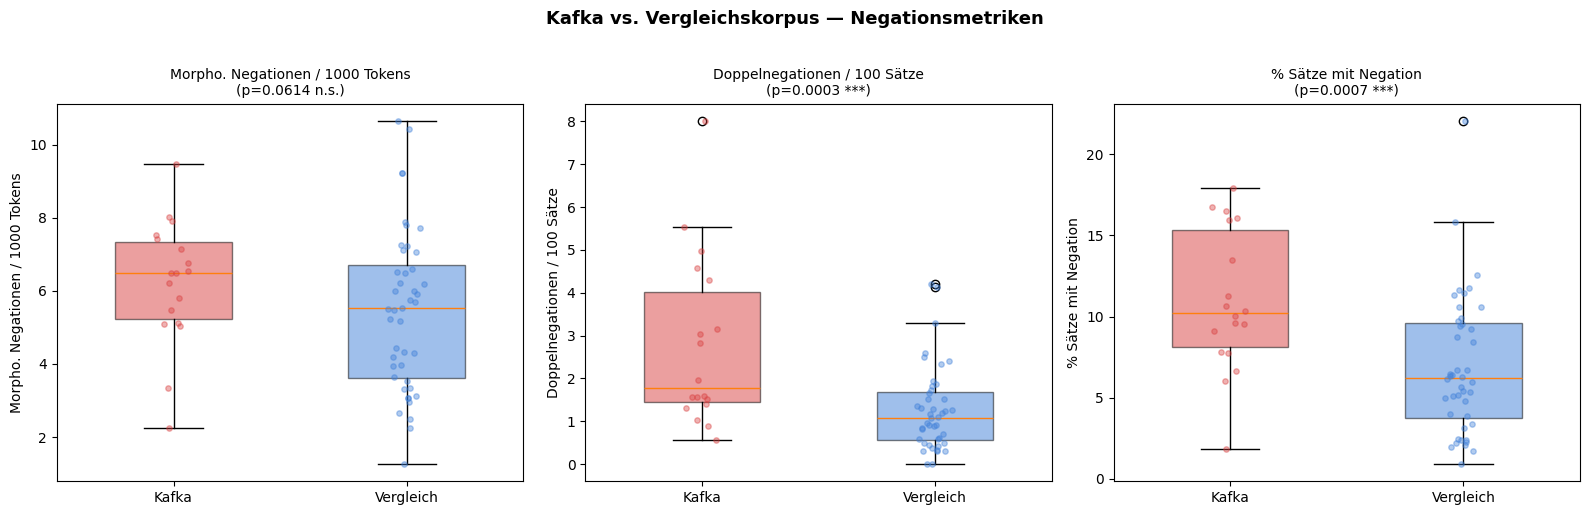

Plot gespeichert: output/mann_whitney_boxplots.png


In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (label, col) in zip(axes, metriken.items()):
    kafka_vals = kafka[col].values
    vergl_vals = vergleich[col].values
    
    # Boxplot
    bp = ax.boxplot(
        [kafka_vals, vergl_vals],
        labels=["Kafka", "Vergleich"],
        patch_artist=True,
        widths=0.5,
    )
    bp["boxes"][0].set_facecolor("#d94040")
    bp["boxes"][0].set_alpha(0.5)
    bp["boxes"][1].set_facecolor("#4080d9")
    bp["boxes"][1].set_alpha(0.5)
    
    # Einzelwerte als Punkte
    np.random.seed(42)
    jitter_k = np.random.normal(1, 0.04, size=len(kafka_vals))
    jitter_v = np.random.normal(2, 0.04, size=len(vergl_vals))
    ax.scatter(jitter_k, kafka_vals, alpha=0.4, color="#d94040", s=15, zorder=3)
    ax.scatter(jitter_v, vergl_vals, alpha=0.4, color="#4080d9", s=15, zorder=3)
    
    # p-Wert annotation
    U, p = mannwhitneyu(kafka_vals, vergl_vals, alternative="greater")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    ax.set_title(f"{label}\n(p={p:.4f} {sig})", fontsize=10)
    ax.set_ylabel(label)

plt.suptitle("Kafka vs. Vergleichskorpus — Negationsmetriken", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(module_path, "output", "mann_whitney_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot gespeichert: output/mann_whitney_boxplots.png")